# Print Results

In [1]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import torch
import deepinv as dinv
from deepinv.physics import Denoising, GaussianNoise, PoissonNoise
from deepinv.utils.demo import load_url_image, get_image_url
from deepinv.utils.plotting import plot

from opt_functions.plot_results import *
        
import ISM.simulation.PSF_sim as ism
import ISM.analysis.Graph_lib as gr

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")



Using device: cuda


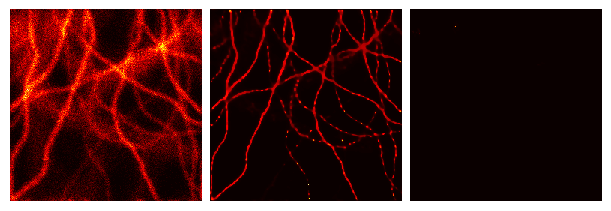

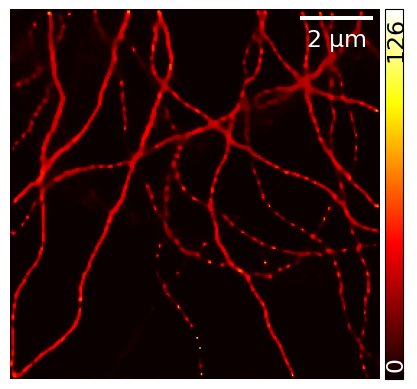

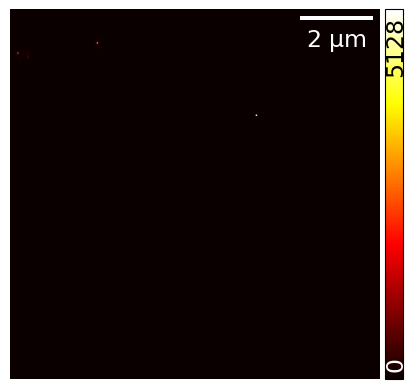

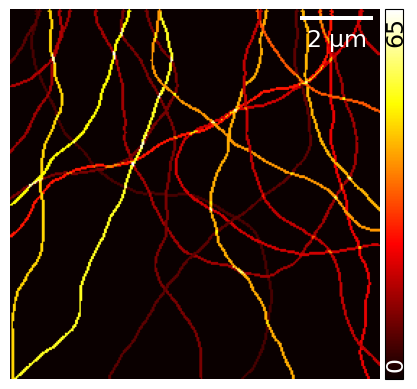

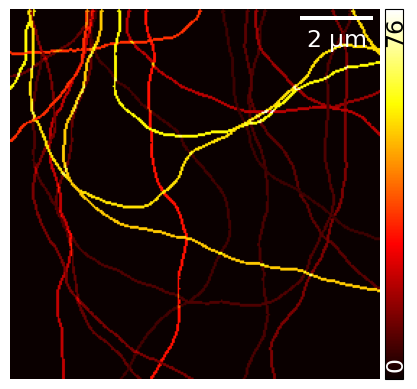

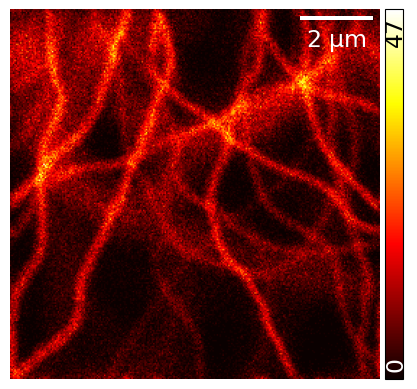

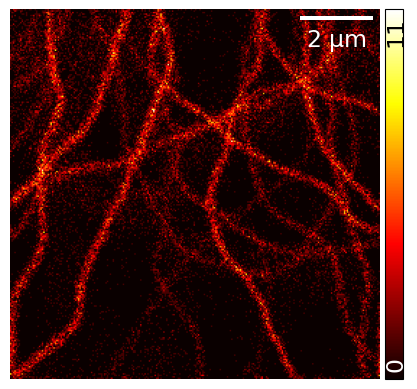

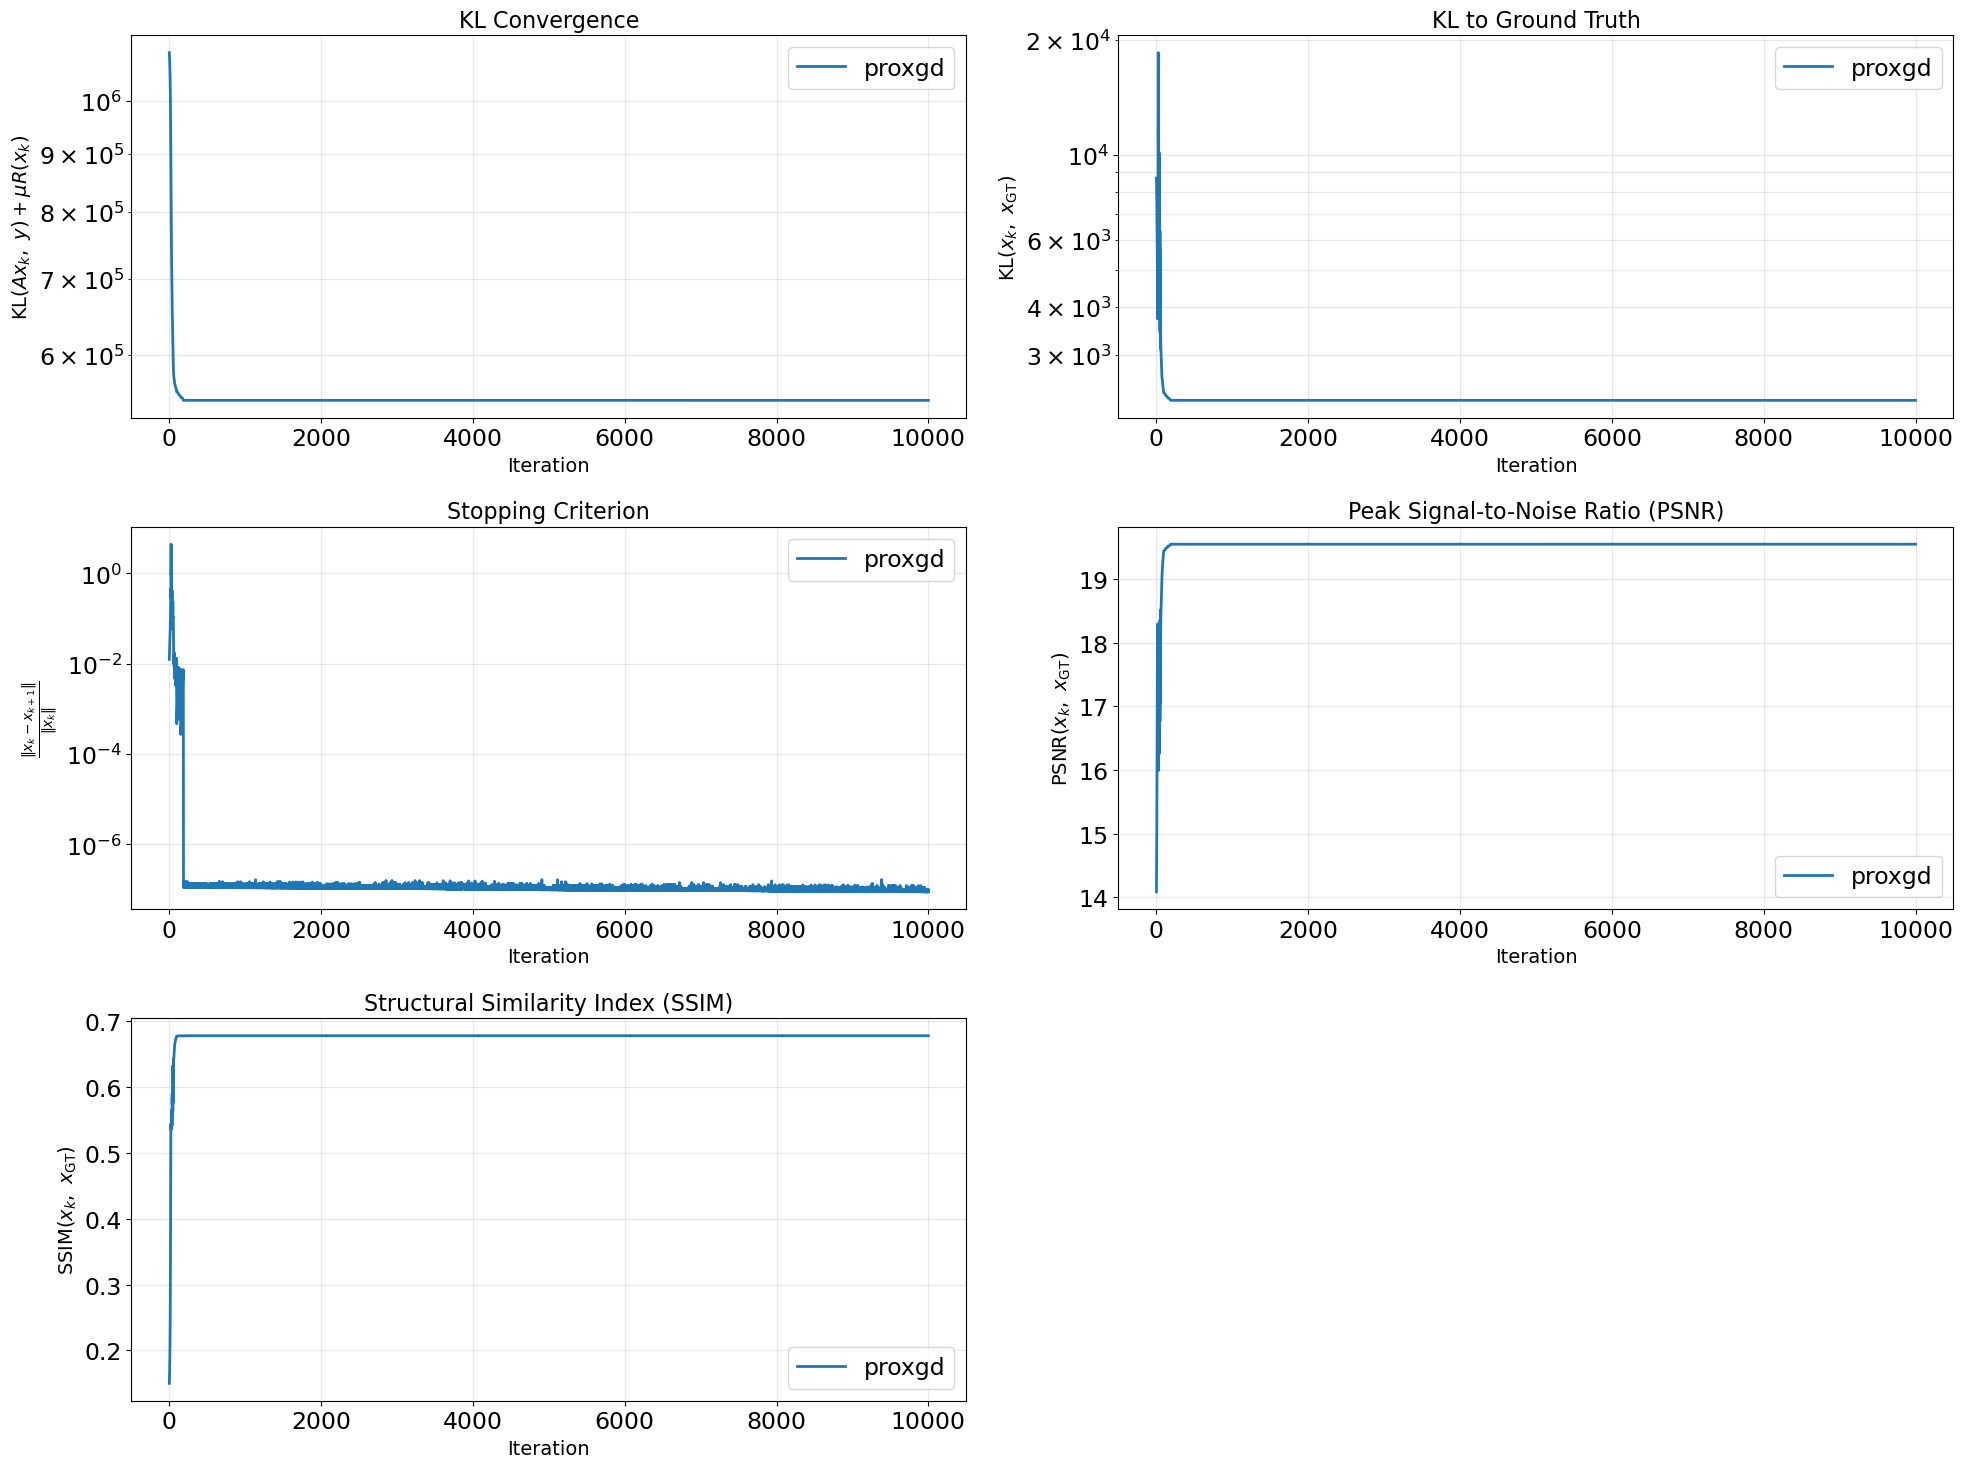

PSNR 19.542518615722656
SSIM 0.6779033541679382
MICROSSIM 0.6913814269779824


In [9]:
lam_to_load = 0

algo_to_load = "pgd"                # pgd or prox or md
name_to_load = "tubulin"     # tubulin for sim
sect_to_load = "2D"                 # 3D or 2D
real_to_load = "sim"               # real o sim

# path = f"Results/ism_results/ism_{sect_to_load}_{real_to_load}_{algo_to_load}_{name_to_load}_lam{lam_to_load}.pth"
path = "Results/ism_results/ism_tv_3D_sim_md_tubulin_lam0.05152.pth"

checkpoint = torch.load(path, weights_only = False)
results = checkpoint['results']
dataset = checkpoint['dataset']
hparams = checkpoint['hparams']


plot_results(results, dataset, hparams['IS_REAL'], hparams['IS_3D'], hparams['pxsize'], x0_sec = 300, y0_sec = 250)


In [28]:
x = dataset["noise_image"]
x_gt = dataset["ground_truth"]
x = x[11:12] / x[11:12].max()
x_gt = x_gt / x_gt.max()
print(f"MICROSSIM {micro_structural_similarity(x_gt.squeeze().detach().cpu().numpy().astype(np.float32), x.squeeze().detach().cpu().numpy().astype(np.float32))}")


MICROSSIM 0.6804549047349255


In [25]:
x1 = results["x_result"][:,0:1]
x = results["x_result"][:,1:2]
x1_masked = x1[x1 != 0]

# Calculate the mean (and extract the Python float using .item())
mean_val = x1_masked.mean().item()

# Get the total number of pixels in a PyTorch Tensor
total_pixels = x.numel()

# Count how many pixels are strictly below the mean
# .item() extracts the single integer from the resulting 0D tensor
num_below_mean = (x < 5).sum().item()

# Calculate the percentage
percentage_below_mean = (num_below_mean / total_pixels) * 100

print(f"Mean value: {mean_val:.4f}")
print(f"Number of pixels below mean: {num_below_mean} out of {total_pixels}")
print(f"Percentage of pixels below mean: {percentage_below_mean:.2f}%")

Mean value: 5.8038
Number of pixels below mean: 52632 out of 65536
Percentage of pixels below mean: 80.31%


In [26]:
x1 = results["x_result"][:,0:1]
x = results["x_result"][:,1:2]

x1_masked = x1[x1 != 0]

# Calcola la media dell'immagine di riferimento (x1)
mean_val = x1_masked.mean().item()

# Crea una maschera logica per i pixel non neri (strettamente maggiori di 0, o != 0)
mask_non_zero = x != 0

# Calcola il numero totale di pixel VALIDI (non neri) in x
total_valid_pixels = mask_non_zero.sum().item()

# Conta quanti pixel NON NERI sono anche SOTTO LA MEDIA di x1
# Usiamo l'operatore bitwise & per combinare le due condizioni
num_below_mean = (mask_non_zero & (x < mean_val)).sum().item()

# Calcola la percentuale (con un piccolo controllo per evitare divisioni per zero)
if total_valid_pixels > 0:
    percentage_below_mean = (num_below_mean / total_valid_pixels) * 100
else:
    percentage_below_mean = 0.0

print(f"Media di riferimento (da x1): {mean_val:.4f}")
print(f"Numero di pixel totali nell'immagine: {x.numel()}")
print(f"Numero di pixel NON neri in x: {total_valid_pixels}")
print(f"Pixel non neri sotto la media: {num_below_mean} su {total_valid_pixels}")
print(f"Percentuale (calcolata solo sui pixel attivi): {percentage_below_mean:.2f}%")

Media di riferimento (da x1): 5.8038
Numero di pixel totali nell'immagine: 65536
Numero di pixel NON neri in x: 26628
Pixel non neri sotto la media: 14483 su 26628
Percentuale (calcolata solo sui pixel attivi): 54.39%


# WHITE PRINCIPLE

--- Risultati per WP ---
Mu ottimale (min WP): 5.354000e-02 con WP = 1.999758e+00
Mu ottimale (max PSNR): 8.788000e-02 con PSNR = 18.3189 dB
Mu ottimale (max SSIM): 8.788000e-02 con SSIM = 0.8089



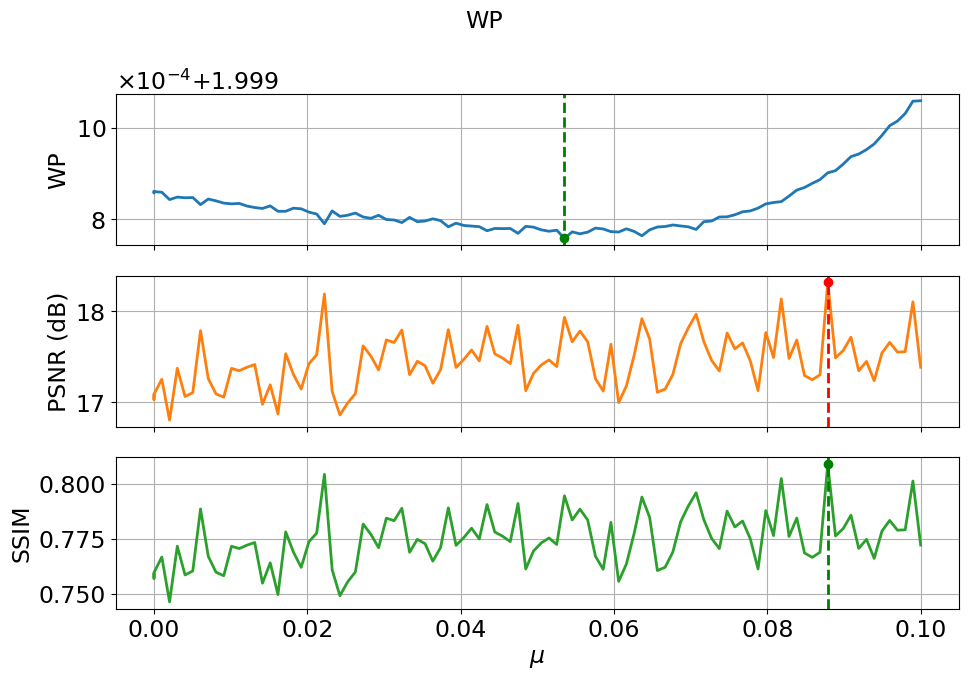

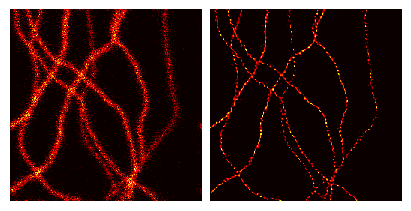

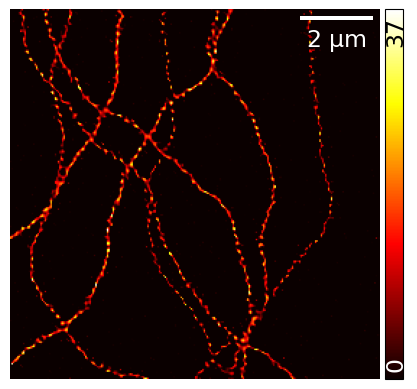

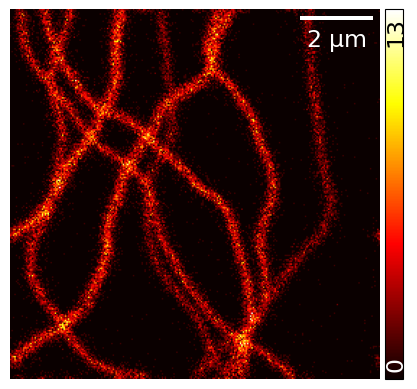

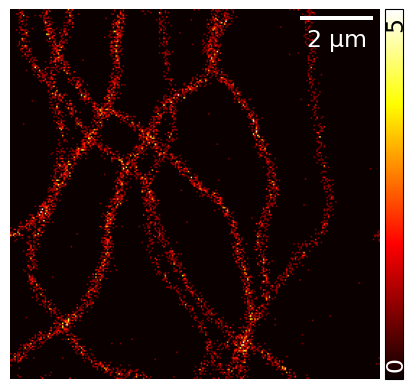

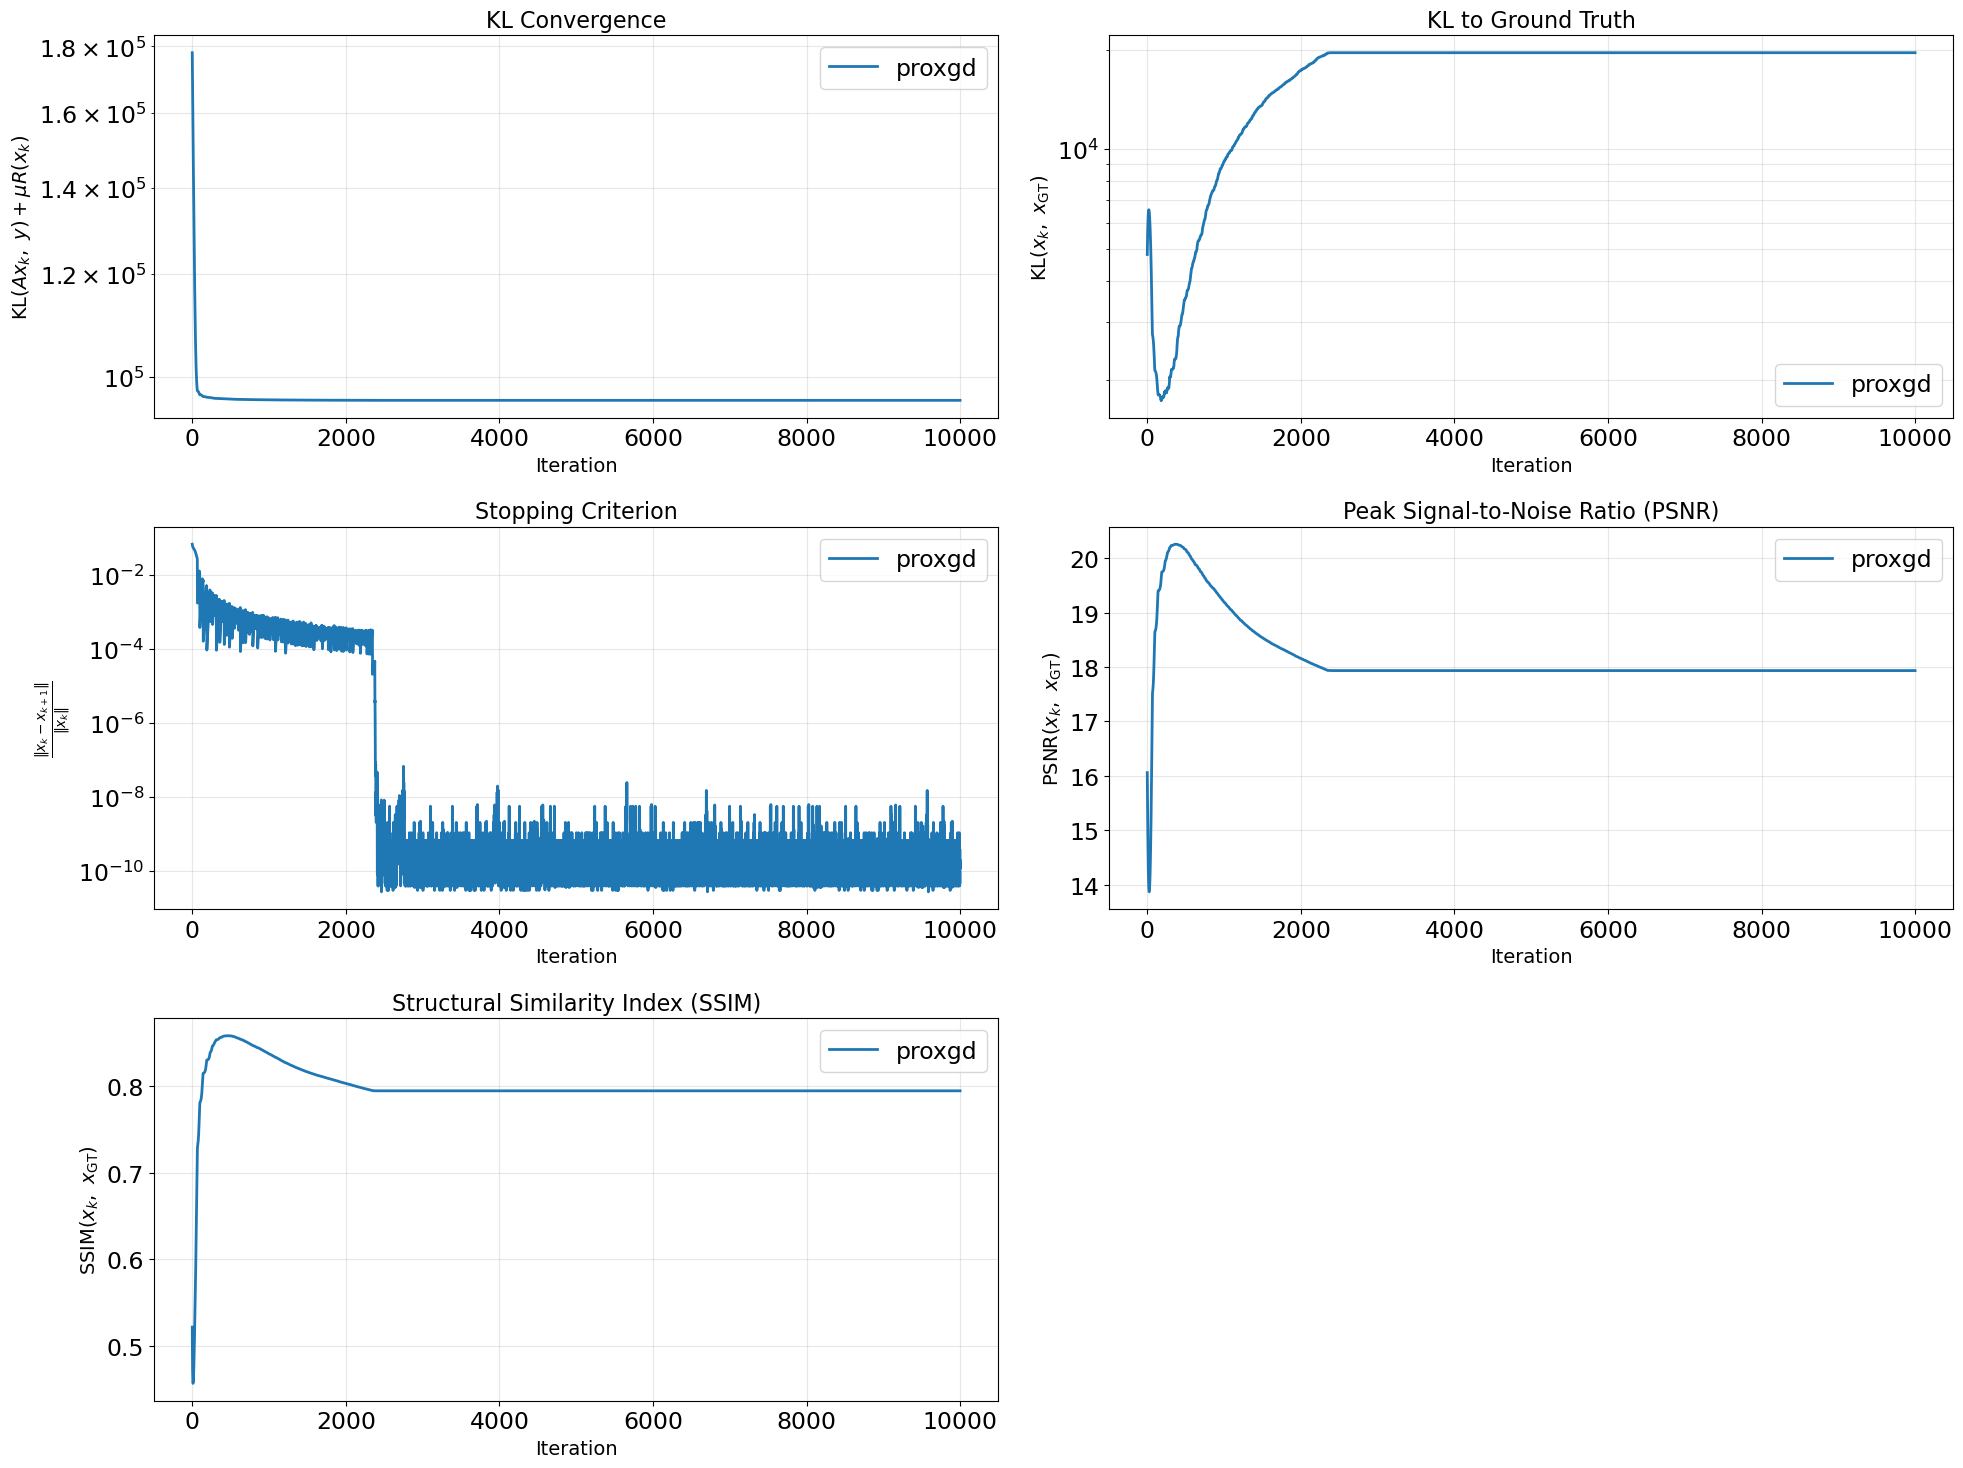

PSNR 17.935134887695312
SSIM 0.794553279876709
MICROSSIM 0.8231343851428816


In [6]:
# path = "Results/WP/wp_3D_pgd_masked_06_convallaria.pth"
mask_type = 'masked'                # whole, masked, masked_eps
algo_to_load = "prox"                # pgd or prox or md
name_to_load = "tubulin"            # tubulin for sim
sect_to_load = "2D"                 # 3D or 2D

path = f"Results/WP/wp_{sect_to_load}_{algo_to_load}_{mask_type}_{name_to_load}.pth"

checkpoint = torch.load(path, weights_only = False)
results = checkpoint['results']
dataset = checkpoint['dataset']
hparams = checkpoint['hparams']

plot_wp_results(hparams['mu_grid'], results, dataset, hparams['pxsize'], is_real= hparams['IS_REAL'], is_3d = hparams['IS_3D'], title="WP", layout="stacked")

# OPTIM WP

In [12]:
results.keys()

dict_keys(['W_sum', 'results_best', 'rwp_vec', 'ground_truth'])

 Miglior mu trovato: 0.277287 con RWP = 184519.3438


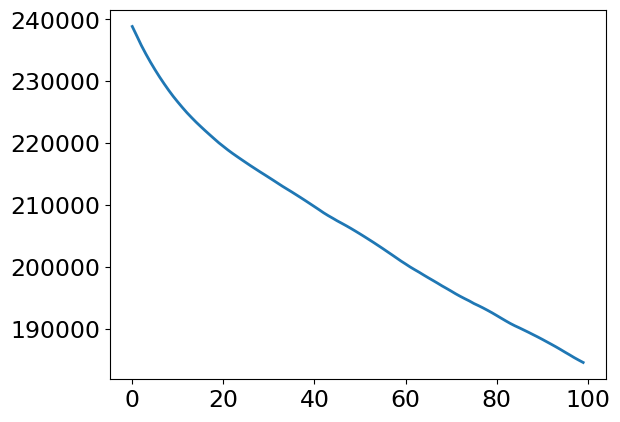

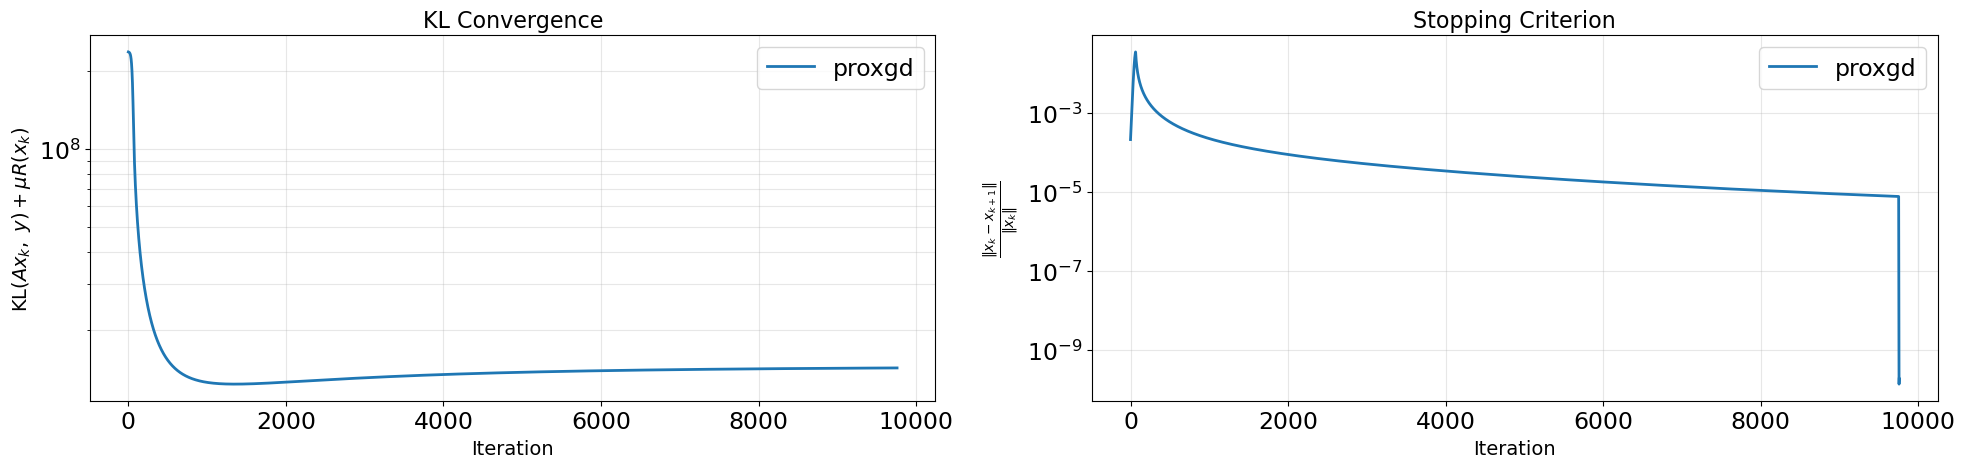

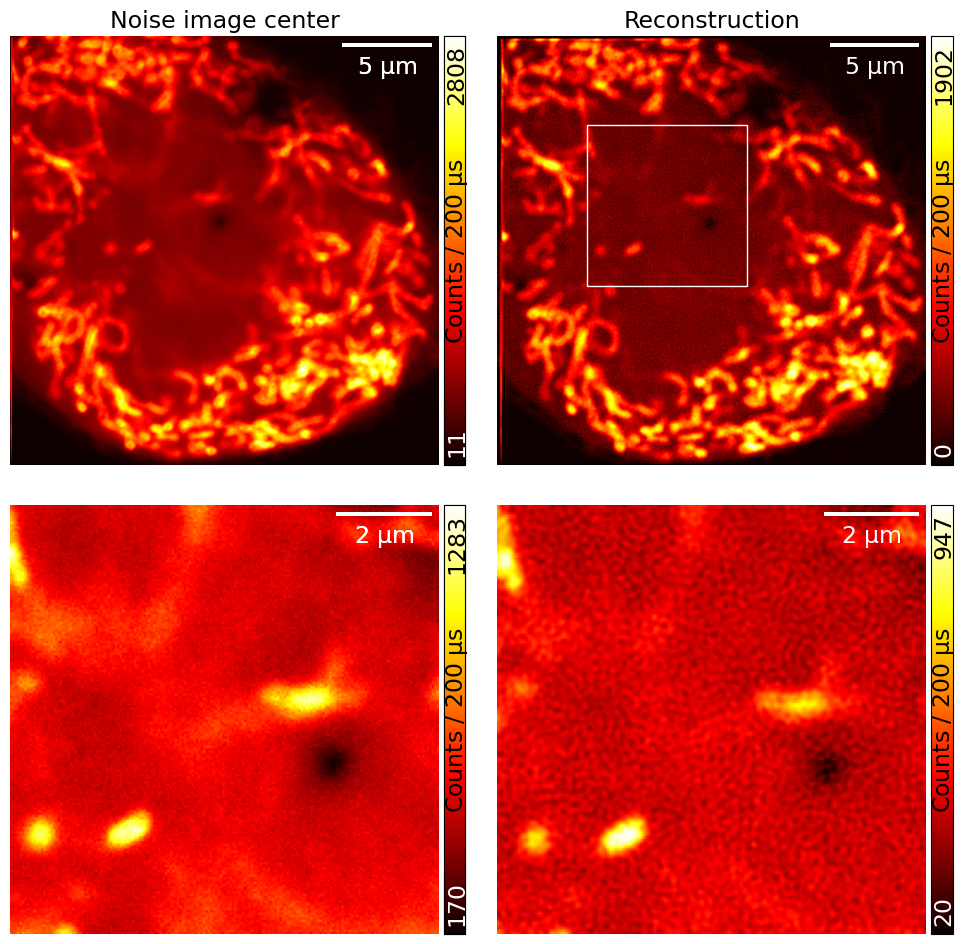

In [18]:
# path = "Results/WP/wp_3D_pgd_masked_06_convallaria.pth"
mask_type = 'masked'                 # whole, masked, masked_eps
algo_to_load = "prox"                # pgd or prox or md
name_to_load = "01_tomm20"     # tubulin for sim
sect_to_load = "3D"                 # 3D or 2D

path = f"Results/WP/wp_optim_{sect_to_load}_{algo_to_load}_{mask_type}_{name_to_load}.pth"


checkpoint = torch.load(path, weights_only = False)
results = checkpoint['results_optim']
best_result = results['results_best']
dataset = checkpoint['dataset']
hparams = checkpoint['hparams']


print(f" Miglior mu trovato: {results['best_mu']:.6f} con RWP = {results['rwp_vec'].min():.4f}")

plt.plot(results['rwp_vec'][100:].cpu())

plot_results(best_result, dataset, hparams['IS_REAL'], hparams['IS_3D'], hparams['pxsize'], x0_sec = 100, y0_sec = 100)
